Decision Trees are powerful but unstable.

Even a small change in the training data can produce a very different tree.

If 4 out of 5 doctors say the patient has diabetes, you're more confident in the diagnosis.

This is exactly how Random Forest works.

Instead of relying on one Decision Tree, it builds many Decision Trees and combines their predictions.

Random forest is a bagging model that uses Bootstrap sampling.Bagging is bootstrap aagregation i.e bagging is a machine learning ensemble technique that uses bootstrap tp train multiple models.

What Are Out-of-Bag Samples?

Suppose

Original Dataset : A B C D E

Tree 1 receives : B A E B C

Which observation

never appeared?

D

D is called an

Out-of-Bag sample

for Tree 1.

We'll use these OOB samples later to estimate model performance without needing a separate validation set.

What are Out-of-Bag samples?

Rows that were not selected in the bootstrap sample for a particular tree.

Production Perspective

Suppose you have

1 million customers.

Random Forest

does not train all trees on one identical dataset.

Instead,

each tree receives

its own

bootstrap sample.

This reduces the risk that the model depends too heavily on peculiarities or noise in one particular sample.

In [21]:
# ==========================================
# 1. Data Manipulation
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# 2. Data Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 3. Machine Learning
# ==========================================
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# ==========================================
# 4. Save Model
# ==========================================
import joblib

# ==========================================
# 5. Ignore Warnings
# ==========================================
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline

In [4]:
df=pd.read_csv(r"C:\Users\Monika Dogra\Desktop\data\diabetes_2.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
print("\nRandom Five Rows")
display(df.sample(5, random_state=42))


Random Five Rows


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
668,6,98,58,33,190,34.0,0.430,43,0
324,2,112,75,32,0,35.7,0.148,21,0
624,2,108,64,0,0,30.8,0.158,21,0
690,8,107,80,0,0,24.6,0.856,34,0
473,7,136,90,0,0,29.9,0.210,50,0


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

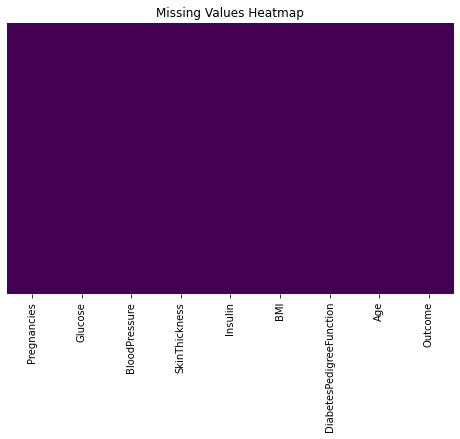

In [8]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


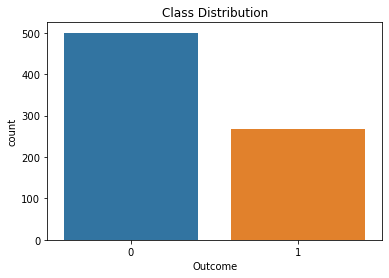

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Outcome",
    data=df
)

plt.title("Class Distribution")

plt.show()

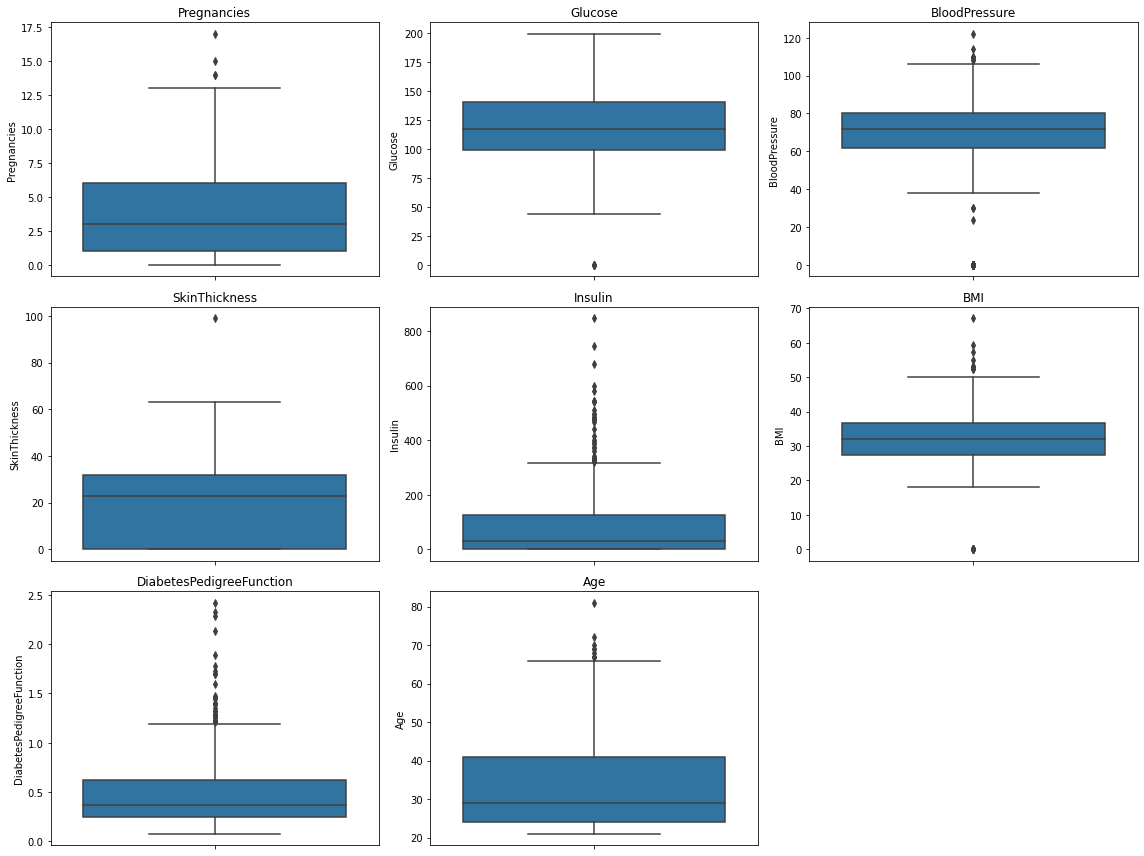

In [12]:
plt.figure(figsize=(16,12))

for i, column in enumerate(df.columns[:-1], 1):

    plt.subplot(3,3,i)

    sns.boxplot(
        y=df[column]
    )

    plt.title(column)

plt.tight_layout()

plt.show()

In [25]:
# outlier detection:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return outliers

outliers = detect_outliers_iqr(df, "Insulin")

print(outliers.shape)

(34, 9)


In [26]:
# count outliers for every column:
for column in df.columns[:-1]:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = df[
        (df[column] < lower) |
        (df[column] > upper)
    ].shape[0]

    print(f"{column}: {count}")

Pregnancies: 4
Glucose: 5
BloodPressure: 45
SkinThickness: 1
Insulin: 34
BMI: 19
DiabetesPedigreeFunction: 29
Age: 9


Percentile Capping

Instead of deleting outliers,

cap them.

Example

Original

450

95th percentile

220

Replace

450

↓

220

In [27]:
# upper = df["Insulin"].quantile(0.95)

# df["Insulin"] = np.where(
#     df["Insulin"] > upper,
#     upper,
#     df["Insulin"]
# )

Winsorization

Winsorization is similar to capping but can cap both lower and upper extremes.

Example

Below 5th percentile  → Replace with 5th percentile

Above 95th percentile → Replace with 95th percentile

Useful when you want to reduce the influence of extreme values without removing observations.

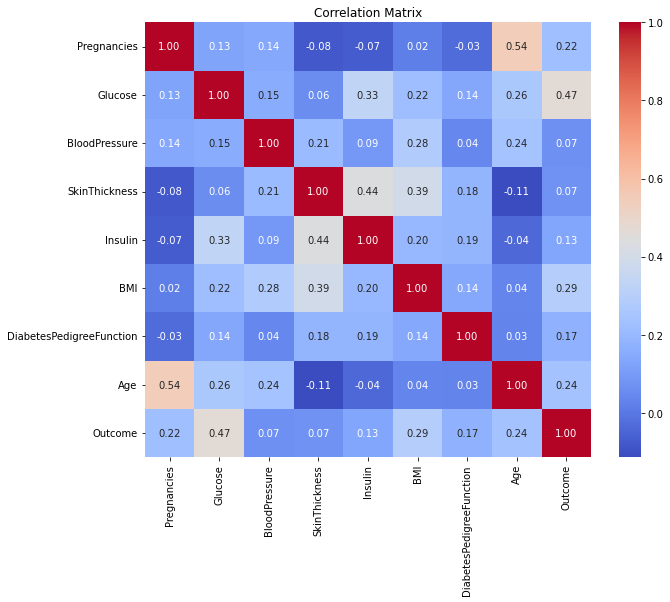

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [14]:
# Feature vs Target Analysis
df.groupby("Outcome").mean(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [15]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [16]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [17]:
# ==========================================================
# Create Pipeline
# =========================================================

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=42))
])

In [22]:
# from sklearn.impute import KNNImputer

# knn = KNNImputer(n_neighbors=5)

# X_train = knn.fit_transform(X_train)

# X_test = knn.transform(X_test)


# Advantages
# More personalized imputation.
# Can preserve relationships between features.
# Disadvantages
# Slower.
# Distance calculations become expensive for large datasets.
# Performance can degrade if features are not on comparable scales.

In [18]:
# ==========================================================
# Hyperparameter Grid
# IMPORTANT:
# Prefix every RandomForest parameter with "model__"
# ==========================================================

param_grid = {

    "model__n_estimators": [100, 200, 300],

    "model__max_depth": [5, 10, 15, None],

    "model__min_samples_split": [2, 5, 10],

    "model__min_samples_leaf": [1, 2, 4],

    "model__max_features": ["sqrt", "log2"]

}

Since your RandomForestClassifier is inside a Pipeline, GridSearchCV cannot see parameters like "n_estimators" directly. You must prefix them with the pipeline step name (model__).

In [19]:
# ==========================================================
# GridSearchCV
# ==========================================================

grid = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring="roc_auc",

    cv=5,

    n_jobs=-1,

    verbose=1

)

# ==========================================================
# Train Model
# ==========================================================

grid.fit(X_train, y_train)

# ==========================================================
# Best Model
# ==========================================================

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

print("\nBest ROC-AUC Score:")
print(grid.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best ROC-AUC Score:
0.8385908084163898


In [20]:
# ==========================================================
# Prediction
# ==========================================================

predictions = best_model.predict(X_test)

probabilities = best_model.predict_proba(X_test)[:, 1]

# ==========================================================
# Evaluation
# ==========================================================

from sklearn.metrics import accuracy_score, roc_auc_score

accuracy = accuracy_score(y_test, predictions)

roc_auc = roc_auc_score(y_test, probabilities)

print("\nAccuracy:", accuracy)

print("ROC-AUC:", roc_auc)


Accuracy: 0.7337662337662337
ROC-AUC: 0.8072222222222222


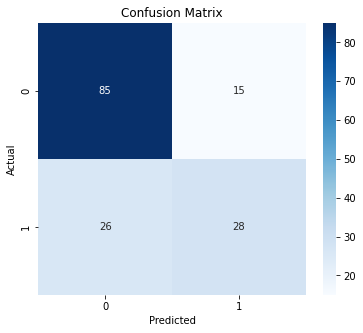

In [30]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [31]:
precision_score(
    y_test,
    predictions
)

0.6511627906976745

In [32]:
recall_score(
    y_test,
    predictions
)

0.5185185185185185

In [33]:
f1_score(
    y_test,
    predictions
)

0.577319587628866

In [34]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       100
           1       0.65      0.52      0.58        54

    accuracy                           0.73       154
   macro avg       0.71      0.68      0.69       154
weighted avg       0.73      0.73      0.73       154



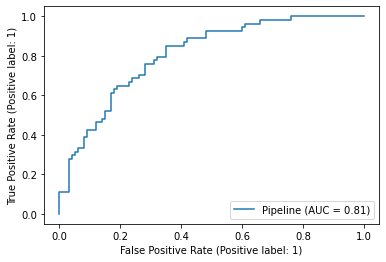

In [36]:
RocCurveDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()

In [37]:
roc_auc_score(
    y_test,
    probabilities
)

0.8072222222222222

In [28]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(accuracy)

0.7337662337662337


In [38]:
scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())

[0.77922078 0.74675325 0.77272727 0.81045752 0.77777778]
0.7773873185637891
